In [1]:
""" model: gpt2
- (Vaswani et al. 2017 https://arxiv.org/abs/1706.03762)
- (Radford et al. 2019 https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- (Brown et al. 2020 https://arxiv.org/abs/2005.14165)

Dimension key:

# windows
B: batch size
T: sequence length

# input/output
V: vocabulary size
D: model dimension (n_embd)

# attention
N: number of transformer blocks (n_layer)
H: number of attention heads in a layer (n_head)
K: size of each attention key or value (n_k)
"""
from dataclasses import dataclass
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(1337)

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

@dataclass
class GPTConfig:
    # windows: B, T
    batch_size: int = -1   # B
    block_size: int = 1024  # T
    # input/output:  V, D
    vocab_size: int = 50257  # V (256 bytes + 50,000 BPE merges + 1 <|endoftext|> token)
    n_embd: int = 768      # D
    # attn: NH
    n_layer: int = 12      # N
    n_head: int = 12       # H

class MHA(nn.Module):
    def __init__(self, config):
        super().__init__()
        T, D, H = config.block_size, config.n_embd, config.n_head
        assert D % H == 0
        self.H = H

        self.c_attn = nn.Linear(D, 3 * D)
        self.c_proj = nn.Linear(D, D)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        self.register_buffer('bias', torch.tril(torch.ones(T, T)).view(1, 1, T, T)) # tril -> bias for HF

    def forward(self, X_BTD):
        B,T,D = X_BTD.shape
        H = self.H
        # 1. project to learned QKV subspaces Q=WqX, K=WkX, V=WvX
        Wq_DK, Wk_DK, Wv_DK = self.c_attn(X_BTD).split(D, dim=2)
        Q_BHTK, K_BHTK, V_BHTK = Wq_DK.view(B, T, H, D // H).transpose(1, 2), Wk_DK.view(B, T, H, D // H).transpose(1, 2), Wv_DK.view(B, T, H, D // H).transpose(1, 2)

        # 2. evaluate scores A(QKV) = softmax(QK^T/sqrt(d_k))V
        A_BHTT = Q_BHTK @ K_BHTK.transpose(-2, -1) * (1.0 / math.sqrt(K_BHTK.size(-1)))
        A_BHTT = A_BHTT.masked_fill(self.bias[:, :, :T, :T]==0, float('-inf'))
        A_BHTT = F.softmax(A_BHTT, dim=-1) # todo, when dim=-1?

        # 3. contextualize the embeddings
        X_BHTK = A_BHTT @ V_BHTK
        X_BTD = X_BHTK.transpose(1, 2).contiguous().view(B, T, D) # performs cat
        X_BTD = self.c_proj(X_BTD)

        return X_BTD

class FFN(nn.Module):
    def __init__(self, config):
        super().__init__()
        D = config.n_embd
        self.c_fc = nn.Linear(D, 4*D) # projecting up to extract features from context embeddings
        self.gelu = nn.GELU(approximate='tanh') # (Hendrycks et al. https://arxiv.org/abs/1606.08415)
        self.c_proj = nn.Linear(4*D, D) # projecting back down to residual pathway
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, X_BTD):
        X_BT4D = self.c_fc(X_BTD)
        X_BT4D = self.gelu(X_BT4D)
        X_BTD = self.c_proj(X_BT4D)
        return X_BTD



class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        D, H = config.n_embd, config.n_head
        self.ln_1 = nn.LayerNorm(D)
        self.attn = MHA(config)
        self.mlp = FFN(config) # .mlp for HF
        self.ln_2 = nn.LayerNorm(D)

    def forward(self, X_BTD):
        # residuals:
        # - (He et al. 2015 https://arxiv.org/abs/1512.03385)
        # - (Elhage et al. 2021 https://transformer-circuits.pub/2021/framework/index.html)
        X_BTD = X_BTD + self.attn(self.ln_1(X_BTD))
        X_BTD = X_BTD + self.mlp(self.ln_2(X_BTD))
        return X_BTD



class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        B, T = config.batch_size, config.block_size
        V, D = config.vocab_size, config.n_embd
        N, H = config.n_layer, config.n_head

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(V, D), # Wt
            wpe = nn.Embedding(T, D), # Wp
            h = nn.ModuleList([Block(config) for _ in range(N)]),
            ln_f = nn.LayerNorm(D),
        ))
        self.lm_head = nn.Linear(D, V, bias=False)

        self.transformer.wte.weight = self.lm_head.weight # weight sharing
        self.apply(self._init_weights) # weight initialization

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std=0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2*self.config.n_layer)**-0.5 # 2: 1 for MHA, 1 for FFN
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, X_BT, Y_BT=None): # Y_BT is optional for inference
        B, T = X_BT.shape
        # 1. embedding: BTD
        Xtok_BTD = self.transformer.wte(X_BT)
        Xpos_TD = self.transformer.wpe(torch.arange(0, T, dtype=torch.long, device=X_BT.device))
        X_BTD = Xtok_BTD + Xpos_TD
        # 2. N transformer blocks: Nx(BTD -> BTK -> BTD)
        for h in self.transformer.h:
            X_BTD = h(X_BTD)
        # 3. logits: BTD -> BTV
        X_BTD = self.transformer.ln_f(X_BTD)
        logits_BTV = self.lm_head(X_BTD)

        loss = None

        # 4. if training, evaluate loss
        if Y_BT is not None:
            B, T, V = logits_BTV.shape # support inference
            loss = F.cross_entropy(logits_BTV.view(B*T, V), Y_BT.view(B*T)) # reshape for .cross_entropy()
        return logits_BTV, loss
 
    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

# model = GPT.from_pretrained('gpt2')
# print('did not crash')

model = GPT(GPTConfig)
model.to(device)

print('model loaded to device')

using device: mps
model loaded to device


loaded 338025 tokens
1 epoch = 2640
step 0, loss: 9.943406105041504
step 1, loss: 9.150611877441406
step 2, loss: 11.916252136230469
step 3, loss: 8.942480087280273
step 4, loss: 9.916420936584473
step 5, loss: 8.16263484954834
step 6, loss: 8.73587417602539
step 7, loss: 8.842891693115234
step 8, loss: 8.024799346923828
step 9, loss: 7.859836578369141
step 10, loss: 8.109477996826172
step 11, loss: 7.471693992614746
step 12, loss: 7.430997371673584
step 13, loss: 7.067662239074707
step 14, loss: 7.227964401245117
step 15, loss: 7.130804061889648
step 16, loss: 6.9421210289001465
step 17, loss: 7.903111457824707
step 18, loss: 6.8504838943481445
step 19, loss: 7.529018402099609
step 20, loss: 7.05308723449707
step 21, loss: 7.331154823303223
step 22, loss: 5.714759826660156
step 23, loss: 6.394985198974609
step 24, loss: 6.1873579025268555
step 25, loss: 5.890632629394531
step 26, loss: 5.877420425415039
step 27, loss: 6.668586730957031
step 28, loss: 6.410289287567139
step 29, loss: 5

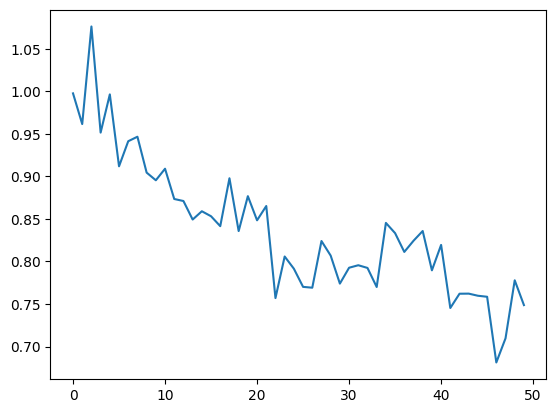

In [2]:
# dataloader + training loop
import tiktoken
import torch
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)
import matplotlib.pyplot as plt
%matplotlib inline

# def gen_dataset(data):
#     ix_rand = torch.randint(len(data) - T, (B,))
#     x = torch.stack([data[i:i+T] for i in ix_rand])
#     y = torch.stack([data[i+1:i+T+1] for i in ix_rand])
#     return x, y

# 1. dataload
class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T

        with open('./data/shakespeare.txt', 'r') as f:
            text = f.read()
        encoder = tiktoken.get_encoding('gpt2')
        tokens = encoder.encode(text)
        self.tokens_N = torch.tensor(tokens)
        self.i = 0
        print(f"loaded {len(self.tokens_N)} tokens")
        print(f"1 epoch = {len(self.tokens_N) // (B*T)}")

    def next_batch(self):
        B, T = self.B, self.T
        buf_BTflat = self.tokens_N[self.i:self.i+(B*T+1)]
        X_BT, Y_BT = buf_BTflat[:-1].view(B, T), buf_BTflat[1:].view(B, T)

        self.i += B*T
        if self.i + (B*T+1) > len(self.tokens_N):
            self.i = 0

        return X_BT, Y_BT

# 2. training loop
steps, losses = [], []
optim = torch.optim.AdamW(model.parameters(), lr=3e-4)
train_loader = DataLoaderLite(B=4, T=32)

for step in range(50):
    X_BT, Y_BT = train_loader.next_batch()
    X_BT, Y_BT = X_BT.to(device), X_BT.to(device)

    optim.zero_grad()
    logits_BTV, loss = model(X_BT, Y_BT)
    loss.backward()
    optim.step()

    print(f"step {step}, loss: {loss.item()}")
    steps.append(step)
    losses.append(loss.log10().item())

plt.plot(steps, losses)
print(loss.item())

# vocab = sorted(list(set(''.join(text))))
# V = len(vocab)

In [3]:
# inference loop
B = 5
T_MAX = 30

# model = GPT.from_pretrained('gpt2')
model = GPT(GPTConfig())
model.eval()
model.to(device)

import tiktoken
encoder = tiktoken.get_encoding('gpt2')
tokens = encoder.encode("Hello, I'm a language model,")
tokens_T = torch.tensor(tokens, dtype=torch.long) # # (T,)
tokens_BT = tokens_T.unsqueeze(0).repeat(5, 1) # (B,T)
X_BT = tokens_BT.to(device)

torch.manual_seed(42)
torch.cuda.manual_seed(42)
while X_BT.size(1) < T_MAX:
    with torch.no_grad():
        logits_BTV, _ = model(X_BT)
        logits_BV = logits_BTV[:, -1, :]
        probs_ = F.softmax(logits_BV, dim=-1)
        topk_probs_, topk_indices_ = torch.topk(probs_, 50, dim=-1)

        X_B1 = torch.gather(topk_indices_, -1, torch.multinomial(topk_probs_, 1))
        X_BT = torch.cat((X_BT, X_B1), dim=1)

for b in range(B):
    tokens = X_BT[b, :T_MAX].tolist()
    decoded = encoder.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model, Recording habittar Percybumbumswitch beginningsproclaimedDX CreSep triple triple Sebastian Vu RedemptionpsonDBspeak gradually Ahmad
> Hello, I'm a language model,imposedpson stage jerk restoredUF colonization restored keRo Fairy RET resists Joel PI aboardFightingift curve indifference Barkley faithfully
> Hello, I'm a language model, losshealthytar Vick enjoyable vulnerableager inclined protectGreatGreatweek ecology Laksh Trophy irrad colonizationAY artificial timing accountable pirates
> Hello, I'm a language model,OUP Jesse FY actresseslvlv steadfastamping proposition WITHMarcoOTAwarts hectares irradTO fury Hutchinson communicates GB GBpiracy
> Hello, I'm a language model,industrial advances fundamentalistcat cheer deal4000 lensesproclaimed safest fit Stranger glac Kod Steinophysicalkanmade lectmask beginnings tasks
